# gold_rate_carry — end-to-end pipeline

This notebook imports and calls the existing modules only; it adds no new analytical logic. Modules live under `src/` (import as `from src import ...`).

In [1]:
import sys, os
# make the repo root (parent of notebooks/) importable regardless of cwd
for _p in (os.getcwd(), os.path.abspath("..")):
    if os.path.isdir(os.path.join(_p, "src")) and _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# report.py switches matplotlib to the Agg backend on import; re-enable the inline
# backend AFTER importing it so this notebook's charts display inline.
from src import loaders, audit, clean, signals, costs, backtest, evaluate, report
%matplotlib inline
import matplotlib.pyplot as plt

LOOKBACK = 20
OOS_START, OOS_END = "2017-01-01", "2025-12-31"
pd.set_option("display.width", 160)

## 1. Data Loading & Audit

This project asks whether gold's price responds to the real interest rate in a way you
could actually trade on. Two series go into that. GLD is SPDR's gold ETF, pulled from
yfinance. DFII10 is the 10 Year TIPS real yield, pulled from FRED. DFII10 isn't something
you can trade directly, it's a published number, so yfinance doesn't carry it.

Both series get checked before they're used anywhere. Hard errors like duplicate dates or
impossible units get raised immediately. Softer anomalies like a big price jump or a
repeated value get flagged for a human to look at rather than fixed automatically. One
thing that's deliberately not flagged is a negative DFII10 reading. Real yields spent long
stretches below zero (2011 to 2013, and again 2020 to 2022), so that's expected, not an
error.

In [2]:
gld = loaders.fetch_gld("2004-11-01", "2026-08-07")
dfii = loaders.load_dfii10()

gld_audit = audit.audit_gld(gld)
dfii_audit = audit.audit_dfii10(dfii)

print("GLD:   ", gld.shape[0], "rows,", gld.index.min().date(), "->", gld.index.max().date())
print("  hard-error checks passed:", gld_audit["hard_errors_checked"])
print("  anomaly summary:", gld_audit["summary"])
print()
print("DFII10:", dfii.shape[0], "rows,", dfii.index.min().date(), "->", dfii.index.max().date())
print("  hard-error checks passed:", dfii_audit["hard_errors_checked"])
print("  anomaly summary:", dfii_audit["summary"])

GLD:    5462 rows, 2004-11-18 -> 2026-08-06
  hard-error checks passed: ['no_duplicate_dates', 'monotonic_increasing_dates', 'no_negative_prices', 'ohlc_consistency', 'price_units_within_bounds']
  anomaly summary: {'mad_outlier_pct_change': 57, 'stale_adj_close': 0, 'zero_volume': 0, 'close_adj_divergence': 0, 'nan_count': 0, 'n_rows': 5462}

DFII10: 6156 rows, 2003-01-02 -> 2026-08-06
  hard-error checks passed: ['no_duplicate_dates', 'monotonic_increasing_dates', 'value_units_within_bounds']
  anomaly summary: {'mad_outlier_change': 24, 'stale_value': 131, 'nan_count': 253, 'n_rows': 6156}


## 2. Data Cleaning

Two things need fixing before the series can be merged, and neither is really about
broken data. No anomalies actually needed correcting here, see `data/decisions.md` for
that review.

The first is timing. FRED labels a DFII10 value by the date it describes, not the date it
was published, and a value dated today usually isn't public until tomorrow. The whole
series gets shifted forward one row so a trading decision only ever uses what was actually
known at the time.

The second is the calendar mismatch. GLD trades on the NYSE calendar. DFII10 gets
published on bond market business days. Those aren't the same set of days. The merge uses
GLD's calendar as the base, and on a day the bond market is closed, the last published
DFII10 value gets carried forward. That's not invented data. Nothing happened to the real
yield that day, there's just no new number to report. GLD itself never gets carried
forward this way.

In [3]:
merged = clean.clean_and_merge(gld, dfii)
print("Merged shape:", merged.shape)
print("Forward-filled DFII10 rows (bond-market holidays):",
      int(merged["dfii10_forward_filled"].sum()))
merged.head()

Merged shape: (5462, 4)
Forward-filled DFII10 rows (bond-market holidays): 232


,gld_close,gld_adj_close,dfii10_aligned,dfii10_forward_filled
date,,,,
2004-11-18,44.380001,44.380001,1.63,False
2004-11-19,44.779999,44.779999,1.64,False
2004-11-22,44.950001,44.950001,1.67,False
2004-11-23,44.750000,44.750000,1.62,False
2004-11-24,45.049999,45.049999,1.65,False


## 3. Signal Construction

Gold pays no coupon, so the cost of holding it instead of something that does pay is
roughly the real interest rate. When real yields fall, that cost falls, and gold should
look more attractive. Model gold as a bond with no coupon and no maturity date and the
math backs this up. Price sensitivity to a change in r grows with T, so an asset with
effectively infinite maturity should be unusually sensitive to rate moves (Barsky &
Summers, 1988).

The real yield matters here specifically, not the nominal one. Nominal yield is roughly
the real yield plus inflation expectations, and those two pieces push gold in opposite
directions. Rising real rates should push gold down through the opportunity cost channel.
Rising inflation expectations should push it up, since gold acts as a partial hedge. Using
DFII10 strips the inflation piece out before it ever reaches the signal.

The rule itself is simple. For a given lookback N, go long GLD if DFII10 has fallen over
the past N trading days, stay flat otherwise. Just the sign, no threshold on the size of
the move, so N stays the only real parameter in the whole strategy. The signal gets
computed every day, but the position only actually changes on each month's first trading
day. That rebalance choice is kept separate from N on purpose, see the note in Section 6
on the tradeoff that creates.

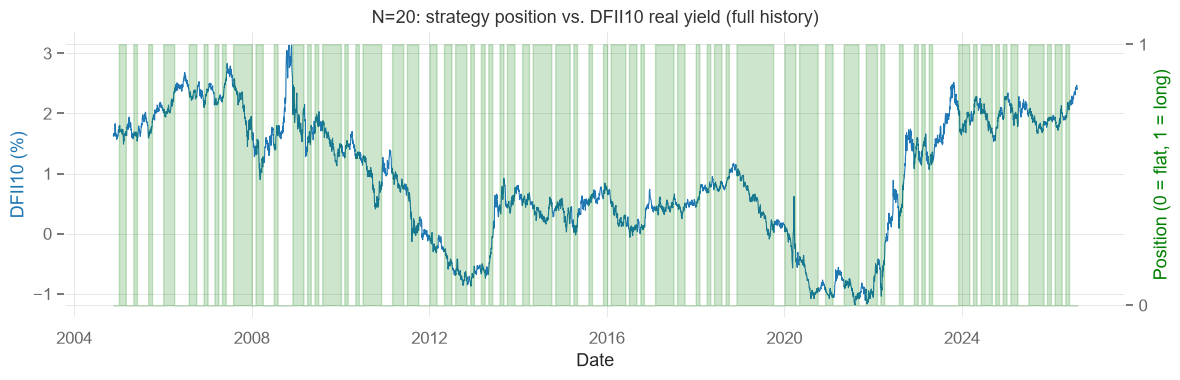

In [4]:
daily_signal = signals.compute_signal(merged, LOOKBACK)
position = signals.apply_monthly_rebalance(daily_signal, merged.index)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(merged.index, merged["dfii10_aligned"], color="#1f77b4", lw=0.8,
         label="DFII10 real yield")
ax1.set_ylabel("DFII10 (%)", color="#1f77b4"); ax1.set_xlabel("Date")
ax2 = ax1.twinx()
ax2.fill_between(position.index, 0, position.fillna(0.0), step="post",
                 color="green", alpha=0.20)
ax2.set_ylabel("Position (0 = flat, 1 = long)", color="green")
ax2.set_ylim(-0.05, 1.05); ax2.set_yticks([0, 1])
ax1.set_title(f"N={LOOKBACK}: strategy position vs. DFII10 real yield (full history)")
fig.tight_layout(); plt.show()

## 4. Backtest

The backtest engine doesn't know or care that this is gold, or that the signal comes from
real yields. It just takes a position series and a price series and runs them through.
That's deliberate, it means the same engine can be pointed at a different strategy later
without rewriting it. Returns are computed as yesterday's position times today's return,
so a decision made today can't accidentally benefit from today's own price move.

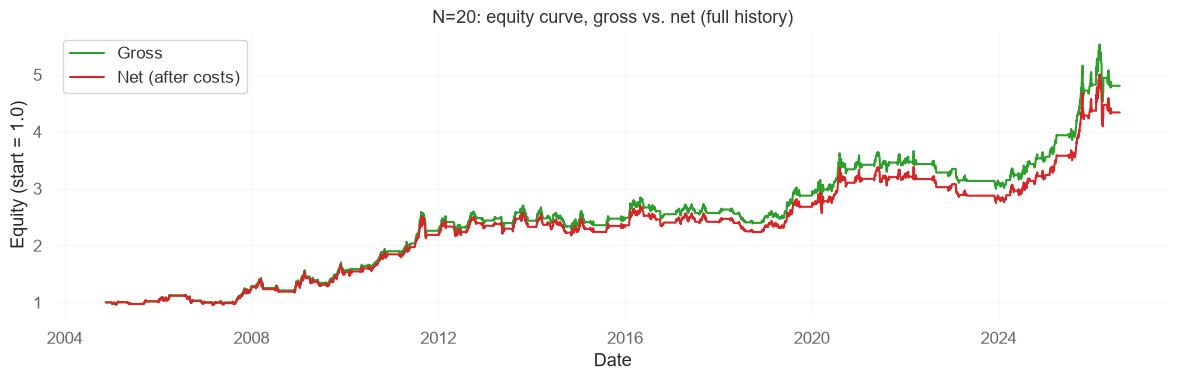

In [5]:
cost_fn = costs.build_cost_fn()   # 8 bps one-way; no separate expense ratio (already in gld_adj_close)
result = backtest.run_backtest(merged["gld_adj_close"], position, cost_fn=cost_fn)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(result["gross_equity_curve"].index, result["gross_equity_curve"],
        color="#2ca02c", label="Gross")
ax.plot(result["equity_curve"].index, result["equity_curve"],
        color="#d62728", label="Net (after costs)")
ax.set_title(f"N={LOOKBACK}: equity curve, gross vs. net (full history)")
ax.set_ylabel("Equity (start = 1.0)"); ax.set_xlabel("Date")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 5. Costs

Two costs get applied, and they're kept separate because they behave differently. A per
trade cost of 8 bps hits only on the days the position actually changes. GLD's own expense
ratio is a different story. The price series used throughout this project
(`gld_adj_close`) already reflects that fee, since the fund sells off a sliver of its gold
holdings continuously to pay for it. Charging it again on top would be double counting a
cost that's already sitting inside the return numbers, so no separate expense ratio
deduction is applied here. Both gross and net returns are shown throughout, since cost
drag is often the difference between a strategy worth pursuing and one that isn't.

In [6]:
# cost_fn's component series are populated by the backtest call in Section 4.
txn = cost_fn.transaction_costs
print(f"Transaction cost (8 bps one-way): total daily drag = {txn.sum():.4f} "
      f"over {int((txn > 0).sum())} trade days")
pd.DataFrame(
    {"total_daily_drag": [txn.sum()],
     "days_charged": [int((txn > 0).sum())]},
    index=["transaction_costs"],
)

Transaction cost (8 bps one-way): total daily drag = 0.1024 over 128 trade days


,total_daily_drag,days_charged
transaction_costs,0.1024,128


## 6. Robustness

Parameter selection happens only on in-sample data, 2005 through 2016. All four candidate
lookbacks (10, 20, 40, 60) get run and reported, not just the winner. N=20 comes out on
top by Sharpe, and it beats 473 of 500 exposure matched random draws, landing at the
94.6th percentile.

Out of sample, 2017 through 2025, N=20 stays frozen, no further tuning. The Sharpe is
positive and holds up under the bootstrap test, but it only ranks at the 36.2nd percentile
against random timing with the same exposure. Most of that OOS gain looks like it's just
gold's own upward drift over the period rather than the signal actually doing anything.

Splitting by regime makes this clearer. From 2008 to 2021, when real yields were mostly
falling or near zero, the strategy beats random timing at the 98.2nd percentile, real
edge. From 2022 to 2024, when real yields spiked, it only beats random timing 8.8% of the
time. The mechanism just doesn't add value once central bank buying takes over as the main
driver of gold demand.

The block bootstrap (21 day blocks, matching the rebalance cycle) backs this up. IS, OOS,
and Regime 1 are all statistically distinguishable from zero. Regime 2 isn't, its 95%
interval runs from −0.89 to 0.88, so with only 36 months of data there's genuinely no way
to tell if that negative number means anything.

Worth being clear about what these two checks actually measure, since they can disagree.
The bootstrap asks whether the Sharpe is reliably above zero, and a strategy can pass that
just from being exposed to an asset that trended up, no real skill required. The random
benchmark asks whether the specific days chosen beat other, randomly chosen days with the
same exposure, which is a much more direct test of whether the signal is doing anything.
That's exactly what happened with OOS, it passes the first test and fails the second.

Cost sensitivity, tested at 5, 8, and 10 bps, doesn't change any of this. OOS stays under
the 50th percentile, Regime 1 stays strong, Regime 2 stays weak, at every level tested.

In [7]:
# Parameter grid (in-sample only): all four lookbacks reported
grid_result = evaluate.run_parameter_grid(merged)
print(grid_result["selection"])
print("IS random-benchmark percentile (winner):",
      grid_result["random_benchmark"]["percentile"])
grid_result["grid"]

selected by highest in-sample Sharpe: N=20, Sharpe=0.6165
IS random-benchmark percentile (winner): 94.6


,lookback,sharpe,calmar,ann_return,ann_vol,max_drawdown,hit_rate,average_exposure,turnover,n_trades,avg_holding_period,total_cost_drag
0,10,0.481424,0.230523,0.059014,0.139354,-0.256001,0.516093,0.586230,6.005958,72,49.194444,0.118124
1,20,0.616548,0.449799,0.075873,0.132986,-0.168682,0.521951,0.533598,6.172790,74,43.567568,0.146504
2,40,0.234632,0.051789,0.022818,0.135395,-0.440601,0.516536,0.542205,5.004965,60,54.600000,0.064532
3,60,0.538859,0.310245,0.067508,0.139263,-0.217596,0.525547,0.584244,3.336643,40,88.250000,0.071110


In [8]:
# Out-of-sample confirmation, N=20 frozen, OOS window explicitly to 2025-12-31
oos = evaluate.run_oos_confirmation(merged, grid_result["winning_lookback"],
                                    oos_end="2025-12-31")
print("OOS random-benchmark percentile:", oos["random_benchmark"]["percentile"],
      "| random-draw mean Sharpe:", round(oos["random_benchmark"]["mean"], 3))
pd.Series(oos["oos_metrics"]).to_frame("OOS 2017-2025")

OOS random-benchmark percentile: 36.2 | random-draw mean Sharpe: 0.731


,OOS 2017-2025
sharpe,0.656327
calmar,0.363171
ann_return,0.068360
ann_vol,0.110007
max_drawdown,-0.188230
hit_rate,0.544957
average_exposure,0.556587
turnover,5.458886
n_trades,49.000000
avg_holding_period,50.360000


**Gross vs. net (OOS 2017–2025, N = 20).** How much the 8 bps per-trade cost erodes each performance metric over the out-of-sample window. Gross figures reuse the Section 4 backtest's gross equity curve; total transaction cost is the gap between gross and net cumulative return.

In [9]:
# Gross vs. net over the OOS window (N=20), reusing the Section 4 backtest output.
import quantstats as qs

net_oos = result["daily_returns"].loc[OOS_START:OOS_END]
gross_oos = result["gross_equity_curve"].pct_change().loc[OOS_START:OOS_END].fillna(0.0)

def _perf(r):
    return {
        "Ann. return": f"{qs.stats.cagr(r) * 100:.1f}%",
        "Ann. vol": f"{qs.stats.volatility(r) * 100:.1f}%",
        "Sharpe": f"{qs.stats.sharpe(r):.3f}",
        "Max drawdown": f"{qs.stats.max_drawdown(r) * 100:.1f}%",
        "Calmar": f"{qs.stats.calmar(r):.3f}",
        "Cumulative return": f"{((1.0 + r).prod() - 1.0) * 100:.1f}%",
    }

gross_col = _perf(gross_oos)
net_col = _perf(net_oos)
gross_col["Total transaction cost"] = "—"  # gross excludes costs by definition
net_col["Total transaction cost"] = (
    f"{((1.0 + gross_oos).prod() - (1.0 + net_oos).prod()) * 100:.2f}%"
)
pd.DataFrame({"Gross": gross_col, "Net": net_col})

,Gross,Net
Ann. return,7.3%,6.8%
Ann. vol,11.0%,11.0%
Sharpe,0.696,0.656
Max drawdown,-18.2%,-18.8%
Calmar,0.402,0.363
Cumulative return,88.3%,81.0%
Total transaction cost,—,7.24%


In [10]:
# Regime split
regimes = evaluate.run_regime_split(merged, grid_result["winning_lookback"])
tbl = pd.DataFrame({
    "Regime 1 (2008-2021)": regimes["regime_1"]["metrics"],
    "Regime 2 (2022-2024)": regimes["regime_2"]["metrics"],
})
tbl.loc["random_benchmark_percentile"] = [
    regimes["regime_1"]["random_benchmark"]["percentile"],
    regimes["regime_2"]["random_benchmark"]["percentile"],
]
tbl

,Regime 1 (2008-2021),Regime 2 (2022-2024)
sharpe,0.607156,-0.025721
calmar,0.417852,-0.036742
ann_return,0.071936,-0.006916
ann_vol,0.127912,0.094850
max_drawdown,-0.172155,-0.188230
hit_rate,0.531445,0.513846
average_exposure,0.581679,0.418327
turnover,5.717527,6.693227
n_trades,80.000000,20.000000
avg_holding_period,51.275000,28.636364


In [11]:
# Block bootstrap significance for all four periods (IS / OOS / Regime 1 / Regime 2)
boot = evaluate.run_block_bootstrap_all_periods(merged, grid_result["winning_lookback"])
pd.DataFrame({
    period: {k: v for k, v in res.items() if k != "draws"}
    for period, res in boot.items()
}).T

,actual_sharpe,bootstrap_mean,bootstrap_std,ci_lower,ci_upper,pct_bootstrap_leq_zero,block_size,n_boot,seed
IS,0.616548,0.631025,0.280849,0.082818,1.186898,0.010,21.0,1000.0,42.0
OOS,0.656327,0.658159,0.309363,0.095626,1.265463,0.011,21.0,1000.0,42.0
regime_1,0.607156,0.568771,0.260136,0.088039,1.100082,0.011,21.0,1000.0,42.0
regime_2,-0.025721,0.030339,0.454442,-0.867494,0.894987,0.465,21.0,1000.0,42.0


In [12]:
# Cost sensitivity across 5 / 8 / 10 bps
cost_sens = evaluate.run_cost_sensitivity(merged, grid_result["winning_lookback"], oos_end="2025-12-31")
print(cost_sens["summary"]["note"])
pd.DataFrame({
    bps: {"OOS Sharpe": d["oos"]["sharpe"], "OOS pct": d["oos"]["percentile"],
          "R1 Sharpe": d["regime_1"]["sharpe"], "R1 pct": d["regime_1"]["percentile"],
          "R2 Sharpe": d["regime_2"]["sharpe"], "R2 pct": d["regime_2"]["percentile"]}
    for bps, d in cost_sens.items() if bps != "summary"
}).T.rename_axis("bps")

All three directional conclusions (OOS underperforms random, Regime 1 beats random, Regime 2 underperforms random) hold at every bps value tested.


,OOS Sharpe,OOS pct,R1 Sharpe,R1 pct,R2 Sharpe,R2 pct
bps,,,,,,
5.0,0.671251,35.8,0.620570,98.2,-0.004551,9.0
8.0,0.656327,36.2,0.607156,98.2,-0.025721,8.8
10.0,0.646363,36.6,0.598203,98.2,-0.039834,8.8


## 7. Charts

The charts below cover the out of sample window, January 2017 through December 2025, net
of costs, benchmarked against GLD buy and hold.

**Chart 1 — Cumulative net performance vs. benchmark** (strategy net equity vs. GLD buy-and-hold, common base).

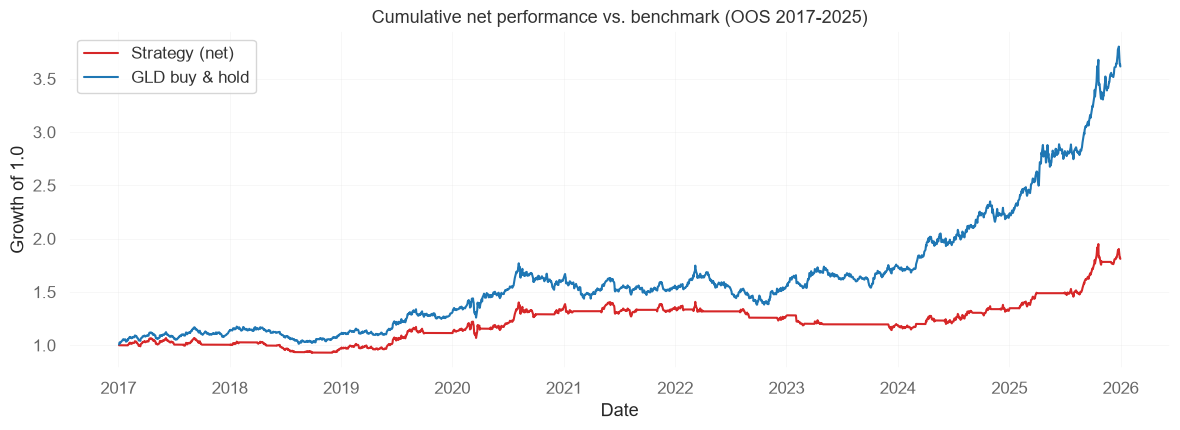

In [13]:
strat_ret_oos = result["daily_returns"].loc[OOS_START:OOS_END]
strat_eq_oos = (1.0 + strat_ret_oos).cumprod()
bench_ret_oos = merged["gld_adj_close"].pct_change().loc[OOS_START:OOS_END].fillna(0.0)
bench_eq_oos = (1.0 + bench_ret_oos).cumprod()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(strat_eq_oos.index, strat_eq_oos, color="#d62728", label="Strategy (net)")
ax.plot(bench_eq_oos.index, bench_eq_oos, color="#1f77b4", label="GLD buy & hold")
ax.set_title("Cumulative net performance vs. benchmark (OOS 2017-2025)")
ax.set_ylabel("Growth of 1.0"); ax.set_xlabel("Date"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 2 — Drawdown** (underwater plot of the strategy's net OOS returns).

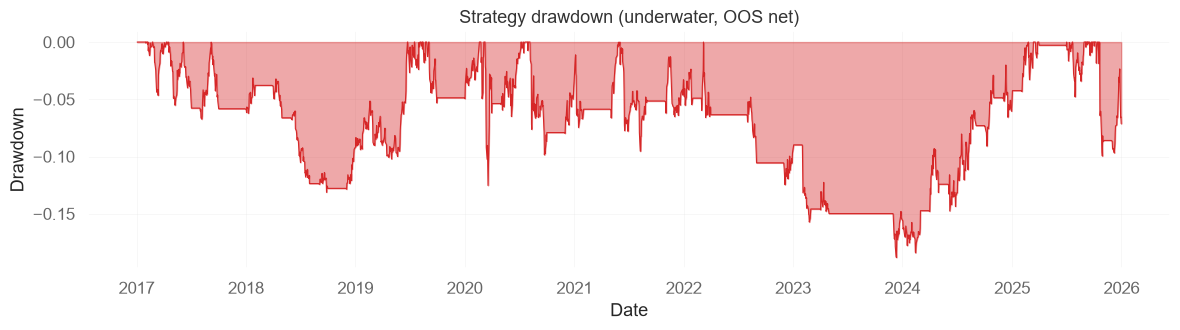

In [14]:
dd = strat_eq_oos / strat_eq_oos.cummax() - 1.0
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(dd.index, dd.values, 0.0, color="#d62728", alpha=0.4)
ax.plot(dd.index, dd.values, color="#d62728", lw=0.8)
ax.set_title("Strategy drawdown (underwater, OOS net)")
ax.set_ylabel("Drawdown"); ax.set_xlabel("Date"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 3 — Rolling Sharpe** (126-trading-day annualized Sharpe over the OOS period).

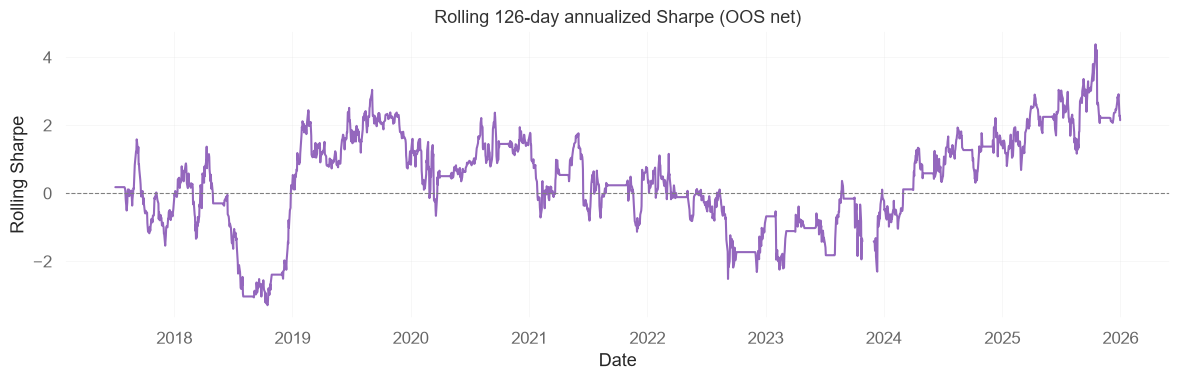

In [15]:
WIN = 126
roll_sharpe = (strat_ret_oos.rolling(WIN).mean()
               / strat_ret_oos.rolling(WIN).std(ddof=1)) * np.sqrt(252)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_sharpe.index, roll_sharpe.values, color="#9467bd")
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_title("Rolling 126-day annualized Sharpe (OOS net)")
ax.set_ylabel("Rolling Sharpe"); ax.set_xlabel("Date"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 4 — Signal / position over time** (long vs. flat across the OOS window).

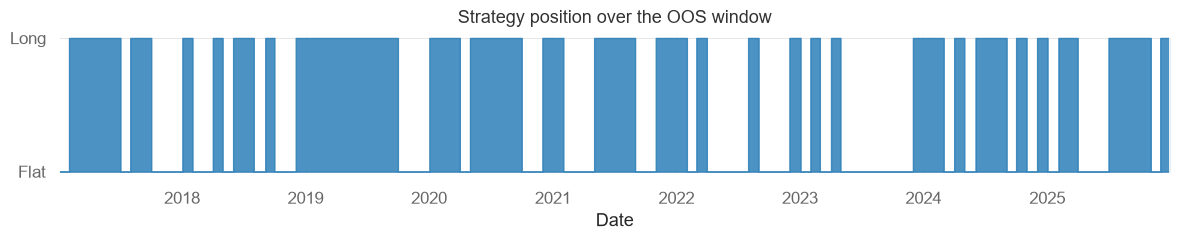

In [16]:
pos_oos = position.loc[OOS_START:OOS_END].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.fill_between(pos_oos.index, 0, pos_oos.values, step="post", color="#2c7fb8", alpha=0.85)
ax.set_ylim(-0.05, 1.05); ax.set_yticks([0, 1]); ax.set_yticklabels(["Flat", "Long"])
ax.set_title("Strategy position over the OOS window")
ax.set_xlabel("Date"); ax.margins(x=0); ax.grid(alpha=0.2, axis="x")
fig.tight_layout(); plt.show()

**Chart 5 — Diagnostic** (GLD price and DFII10 real yield on dual axes; green = strategy long).

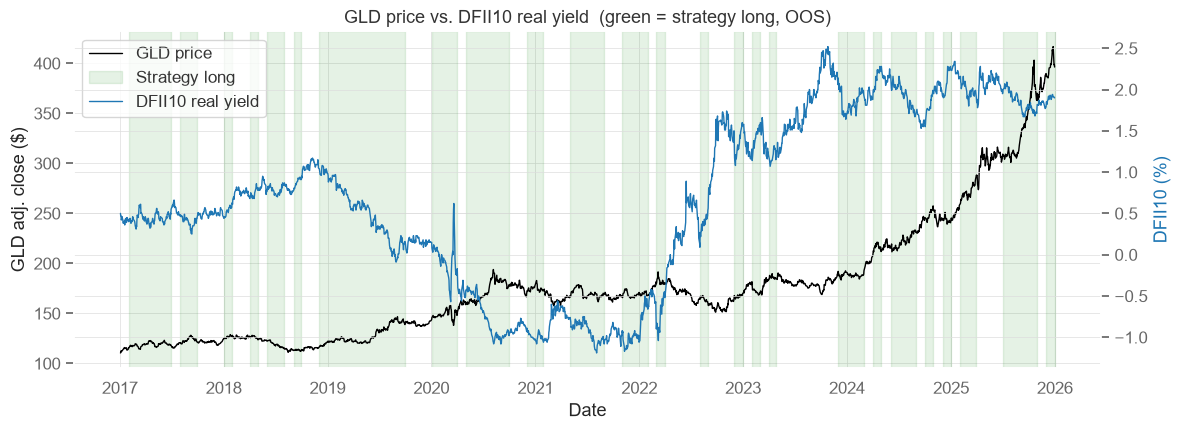

In [17]:
oos_slice = merged.loc[OOS_START:OOS_END]
long_mask = pos_oos.to_numpy() == 1.0
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(oos_slice.index, oos_slice["gld_adj_close"], color="black", lw=1.0, label="GLD price")
ax1.set_ylabel("GLD adj. close ($)"); ax1.set_xlabel("Date")
ax2 = ax1.twinx()
ax2.plot(oos_slice.index, oos_slice["dfii10_aligned"], color="#1f77b4", lw=1.0,
         label="DFII10 real yield")
ax2.set_ylabel("DFII10 (%)", color="#1f77b4")
ax1.fill_between(pos_oos.index, 0, 1, where=long_mask, transform=ax1.get_xaxis_transform(),
                 color="green", alpha=0.10, label="Strategy long")
ax1.set_title("GLD price vs. DFII10 real yield  (green = strategy long, OOS)")
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")
fig.tight_layout(); plt.show()

Finally, `report.py` assembles all of the above (verdict + charts + QuantStats tearsheet) into a single self-contained HTML file.

In [18]:
report.generate_report(merged)
print("Standalone HTML report written to result/report.html")

Standalone HTML report written to result/report.html


## 8. Conclusion

Verdict: Monitor.

The mechanism is real. It holds up statistically in the regime it was actually tested
against (2008 to 2021). It's not ready to pursue as is, because the 2022 to 2024 period
shows it adds no value once central bank buying takes over as gold's main demand driver.
It doesn't warrant a flat rejection either, given how clean the edge was before that, and
how specific the reason for the breakdown is.

The biggest limitation here is that the 2022 regime boundary wasn't found blind. It was
picked knowing the relationship had already broken down publicly by that point. So this
confirms a known story rather than discovering a new one.

Central bank buying has stayed well above its pre 2022 average through 2024 and 2025, so
this doesn't look like a short term reaction that's about to fade. Whether the real yield
channel comes back, or central bank demand just becomes a permanent feature of how gold
gets priced, is the open question that should decide whether this strategy gets revisited.